# Distributed ML with Ray — the hands-on half

The practical companion to **`ray_slides.html`**. Everything here runs on the cores you already
have; nothing needs a cluster. The point is that the *code* does not change when a cluster does
appear.

| Part | Deck slides | What you do |
|---|---|---|
| 0 · Setup | 11 | install, start a local Ray, see your resources |
| 1 · Tasks | 12–13 | `@ray.remote`, and a **measured** speedup across your cores |
| 2 · The object store | 8 | why `ray.put` matters, measured on a big array |
| 3 · Actors | 14 | state that lives beside the work |
| 4 · Ray Train | 16–18 | data-parallel PyTorch, same script for 1 or 100 workers |
| 5 · Advanced | 19–22 | `ray.wait`, resources, failures, when not to use Ray |

Everything runs in a throwaway `ray_demo/` folder; the last cell shuts Ray down.

## Step 0.1 · Install

In [1]:
!pip install -q 'ray[train]' scikit-learn pandas matplotlib

## Step 0.2 · A sandbox to work in

In [2]:
import os, shutil, pathlib

BASE = pathlib.Path.cwd()          # the folder this notebook lives in
PROJ = BASE / "ray_demo"           # a throwaway sandbox, deleted by the last cell

if PROJ.exists():
    shutil.rmtree(PROJ)            # re-running this notebook is always safe
PROJ.mkdir(parents=True)
os.chdir(PROJ)
print("working inside:", os.getcwd())

working inside: /home/shamaseen/Desktop/Shai/qafza/free_Training/qafza-free-traning/08-distributed-ml/ray_demo


## Step 0.3 · Start Ray, and look at what you have

`ray.init()` with no arguments starts a **local cluster**: one node, using this machine's cores.
Point it at an address instead and the same code runs on a hundred machines — that is the whole
proposition.

In [3]:
import os, time, math, numpy as np, pandas as pd, ray

# quieten the dashboard/log spam for a notebook; drop these in a script
ray.init(ignore_reinit_error=True, log_to_driver=False,
         include_dashboard=False, configure_logging=False)

res = ray.cluster_resources()
CPUS = int(res.get("CPU", 1))
print(f"ray {ray.__version__}")
print(f"nodes: {len(ray.nodes())}   CPU: {CPUS}   "
      f"object store: {res.get('object_store_memory', 0)/1e9:.1f} GB")

/home/shamaseen/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/shamaseen/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


ray 2.51.2
nodes: 1   CPU: 16   object store: 4.7 GB


/home/shamaseen/anaconda3/lib/python3.9/site-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


---
# Part 1 — Tasks   ·   deck slides 12–13

A **task** is a function you have marked as remote. Calling it does not run it — it returns a
reference immediately and the work happens somewhere else.

Two rules explain nearly all of Ray:

* `f.remote(...)` returns an `ObjectRef` **straight away** (non-blocking)
* `ray.get(ref)` waits for the value

In [4]:
def slow_square(x):
    """Stand-in for real work: a CPU-bound function that takes a while."""
    total = 0.0
    for i in range(2_000_000):
        total += math.sqrt(i % 97)
    return x * x + 0.0 * total


@ray.remote
def slow_square_remote(x):
    total = 0.0
    for i in range(2_000_000):
        total += math.sqrt(i % 97)
    return x * x + 0.0 * total


N = max(8, CPUS)
t0 = time.perf_counter()
serial = [slow_square(i) for i in range(N)]
t_serial = time.perf_counter() - t0
print(f"serial:   {N} items in {t_serial:6.2f}s")

serial:   16 items in   1.59s


In [5]:
t0 = time.perf_counter()
refs = [slow_square_remote.remote(i) for i in range(N)]   # returns immediately
print(f"submitted {N} tasks in {(time.perf_counter()-t0)*1000:.1f} ms -- nothing has run yet")
print("first ref:", refs[0])

t0 = time.perf_counter()
parallel = ray.get(refs)                                   # now we wait
t_parallel = time.perf_counter() - t0

assert serial == parallel, "the parallel answer must equal the serial one"
print(f"\nserial:   {t_serial:6.2f}s")
print(f"parallel: {t_parallel:6.2f}s   on {CPUS} cores")
print(f"speedup:  {t_serial/t_parallel:6.2f}x")
assert t_serial / t_parallel > 1.5, "parallel execution should be meaningfully faster"

submitted 16 tasks in 35.7 ms -- nothing has run yet
first ref: ObjectRef(c8ef45ccd0112571ffffffffffffffffffffffff0100000001000000)

serial:     1.59s
parallel:   0.38s   on 16 cores
speedup:    4.17x


### Why the speedup is not equal to your core count

* starting and scheduling each task costs something (roughly a millisecond)
* results must be serialised back
* your cores are shared with everything else on the machine
* and the GIL is only escaped because each task is a **separate process**

That last point is why this works at all: `threading` would not help here, because the work is
CPU-bound Python.

In [6]:
# how the speedup behaves as you add work -- the shape matters more than the peak
sizes = [1, 2, 4, 8, 16]
measured = []
for n in sizes:
    t0 = time.perf_counter(); ray.get([slow_square_remote.remote(i) for i in range(n)])
    dt = time.perf_counter() - t0
    measured.append((n, dt, (n * (t_serial / N)) / dt))
    print(f"  {n:2} tasks: {dt:5.2f}s   effective speedup {measured[-1][2]:5.2f}x")

   1 tasks:  0.11s   effective speedup  0.93x
   2 tasks:  0.11s   effective speedup  1.83x
   4 tasks:  0.11s   effective speedup  3.61x
   8 tasks:  0.18s   effective speedup  4.30x
  16 tasks:  0.28s   effective speedup  5.60x


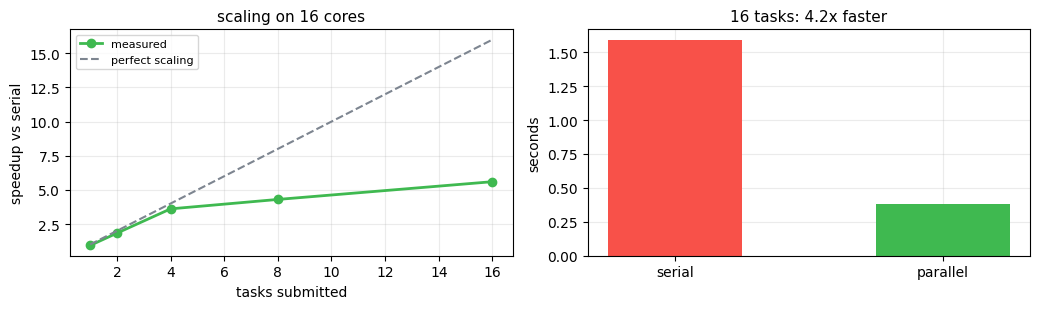

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
ns = [m[0] for m in measured]; sp = [m[2] for m in measured]
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.2))
ax[0].plot(ns, sp, "o-", color="#3fb950", lw=2, label="measured")
ax[0].plot(ns, ns, "--", color="#7d8590", label="perfect scaling")
ax[0].set_xlabel("tasks submitted"); ax[0].set_ylabel("speedup vs serial")
ax[0].set_title(f"scaling on {CPUS} cores", fontsize=11); ax[0].legend(fontsize=8)
ax[1].bar(["serial", "parallel"], [t_serial, t_parallel], color=["#f85149", "#3fb950"], width=.5)
ax[1].set_ylabel("seconds"); ax[1].set_title(f"{N} tasks: {t_serial/t_parallel:.1f}x faster", fontsize=11)
for a in ax: a.grid(alpha=.25); a.set_axisbelow(True)
fig.tight_layout(); plt.show()

---
# Part 2 — The object store   ·   deck slides 8

Ray keeps task arguments and results in a **shared-memory object store** on each node. This is
not a detail: it decides whether your parallel code is fast or slower than serial.

If you pass a large object into ten tasks, it is serialised ten times. `ray.put` puts it in the
store **once** and hands the tasks a reference.

In [8]:
big = np.random.rand(4_000_000)          # ~32 MB
print(f"array: {big.nbytes/1e6:.0f} MB")

@ray.remote
def mean_of(a):
    return float(a.mean())

# 1. pass the array itself, ten times
t0 = time.perf_counter()
by_value = ray.get([mean_of.remote(big) for _ in range(10)])
t_value = time.perf_counter() - t0

# 2. put it in the store once, pass the reference
handle = ray.put(big)
t0 = time.perf_counter()
by_ref = ray.get([mean_of.remote(handle) for _ in range(10)])
t_ref = time.perf_counter() - t0

assert abs(by_value[0] - by_ref[0]) < 1e-12
print(f"passing the array each time : {t_value:6.3f}s")
print(f"ray.put once, pass the ref  : {t_ref:6.3f}s")
print(f"                              {t_value/max(t_ref,1e-9):5.2f}x")

array: 32 MB
passing the array each time :  0.043s
ray.put once, pass the ref  :  0.013s
                               3.42x


> **The rule:** anything large that several tasks need should be `ray.put` first. Model weights,
> a lookup table, a dataframe. Ray warns you about this in real workloads — a task whose
> arguments are large is the most common cause of "Ray made it slower".
>
> Objects in the store are **immutable**. That is what makes zero-copy sharing safe.

---
# Part 3 — Actors   ·   deck slides 14

A task is stateless. An **actor** is a class whose instance lives in its own process and keeps
state between calls — a loaded model, a connection pool, a running counter.

In [9]:
@ray.remote
class Scorer:
    """A model that is loaded once, then answers many calls."""
    def __init__(self, weights):
        self.w = weights          # imagine 500 MB of model here
        self.n = 0

    def score(self, x):
        self.n += 1
        return float(np.dot(self.w, x))

    def calls(self):
        return self.n


w = np.random.rand(64)
scorer = Scorer.remote(w)                      # one process, holds the weights

vals = ray.get([scorer.score.remote(np.random.rand(64)) for _ in range(50)])
print(f"50 scores, first three: {[round(v,3) for v in vals[:3]]}")
print(f"the actor counted: {ray.get(scorer.calls.remote())} calls -- state survived between them")
assert ray.get(scorer.calls.remote()) == 50

50 scores, first three: [14.342, 12.029, 14.404]
the actor counted: 50 calls -- state survived between them


In [10]:
# a pool of actors: the standard pattern for "load the model once per worker"
POOL = min(4, CPUS)
pool = [Scorer.remote(w) for _ in range(POOL)]

work = [np.random.rand(64) for _ in range(200)]
t0 = time.perf_counter()
refs = [pool[i % POOL].score.remote(x) for i, x in enumerate(work)]   # round-robin
out = ray.get(refs)
print(f"{len(out)} scores across {POOL} actors in {(time.perf_counter()-t0)*1000:.0f} ms")
print("calls per actor:", ray.get([a.calls.remote() for a in pool]))

200 scores across 4 actors in 438 ms
calls per actor: [50, 50, 50, 50]


| Use a task | Use an actor |
|---|---|
| stateless work | something expensive to set up |
| each call independent | a model, a connection, a cache |
| easy to retry | you need it to stay warm |

**Actors do not scale by themselves.** One actor is one process handling one call at a time; you
create a pool. Ray Serve (session 11) is a managed pool of actors with autoscaling.

---
# Part 4 — Ray Train   ·   deck slides 16–18

The same PyTorch loop from session 2, distributed. You write a `train_func` that runs on **each**
worker; Ray Train handles process groups, sharding and reporting.

In [11]:
import torch
from torch import nn
import ray.train
from ray.train import ScalingConfig, RunConfig
from ray.train.torch import TorchTrainer

# data lives in the object store, so every worker reads one copy
rng = np.random.default_rng(0)
X = rng.normal(size=(8000, 10)).astype("float32")
w_true = rng.normal(size=10)
y = ((X @ w_true + rng.normal(0, .5, 8000)) > 0).astype("float32")
DATA = ray.put((X, y))


@ray.remote
class MetricsLog:
    """A collector actor. ray.train.report is the idiomatic call, but what
    Result.metrics contains has moved between Ray versions -- an actor we own is
    version-proof, and it is a genuinely useful pattern in its own right."""
    def __init__(self):
        self.rows = []

    def add(self, row):
        self.rows.append(row)

    def all(self):
        return self.rows


def train_func(config):
    """Runs on EVERY worker. ray.train.torch prepares the model and the loader."""
    import numpy as np, torch, ray, ray.train
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset

    X, y = ray.get(config["data"])
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y).unsqueeze(1))
    dl = DataLoader(ds, batch_size=64, shuffle=True)
    dl = ray.train.torch.prepare_data_loader(dl)        # shards across workers

    model = ray.train.torch.prepare_model(
        nn.Sequential(nn.Linear(10, 32), nn.ReLU(), nn.Linear(32, 1)))   # wraps in DDP
    opt = torch.optim.AdamW(model.parameters(), lr=3e-3)
    loss_fn = nn.BCEWithLogitsLoss()
    rank = ray.train.get_context().get_world_rank()

    for epoch in range(config["epochs"]):
        model.train(); total = 0.0; n = 0
        for xb, yb in dl:
            opt.zero_grad(set_to_none=True)
            loss = loss_fn(model(xb), yb)
            loss.backward(); opt.step()
            total += loss.item() * len(xb); n += len(xb)
        row = {"rank": rank, "epoch": epoch, "loss": total / max(n, 1), "rows_seen": n}
        ray.train.report(row)                     # idiomatic: Tune and checkpointing use it
        ray.get(config["log"].add.remote(row))    # and ours, which we can read back


log = MetricsLog.remote()
WORKERS = 2
trainer = TorchTrainer(
    train_loop_per_worker=train_func,
    train_loop_config={"epochs": 5, "data": DATA, "log": log},
    scaling_config=ScalingConfig(num_workers=WORKERS, use_gpu=False),
    run_config=RunConfig(storage_path=os.path.abspath("ray_results"), name="demo"),
)
result = trainer.fit()
ok = result.error is None
print(f"finished on {WORKERS} workers; trainer reported failure: {not ok}")
assert ok, result.error


finished on 2 workers; trainer reported failure: False


In [12]:

hist = pd.DataFrame(ray.get(log.all.remote())).sort_values(["epoch", "rank"])
print(hist.to_string(index=False))

per_epoch = hist.groupby("epoch").loss.mean()
print(f"\nmean loss: epoch 0 {per_epoch.iloc[0]:.4f}  ->  epoch {per_epoch.index[-1]} "
      f"{per_epoch.iloc[-1]:.4f}")
print(f"each worker saw {int(hist.rows_seen.iloc[0])} of {len(X)} rows -- the loader sharded the data")

assert len(hist) == WORKERS * 5, "every worker should report every epoch"
assert per_epoch.iloc[-1] < per_epoch.iloc[0], "the loss must come down"
assert hist.rows_seen.iloc[0] < len(X), "prepare_data_loader must shard, not duplicate"


 rank  epoch     loss  rows_seen
    0      0 0.521800       4000
    1      0 0.523349       4000
    0      1 0.235049       4000
    1      1 0.238429       4000
    0      2 0.158866       4000
    1      2 0.161235       4000
    0      3 0.142501       4000
    1      3 0.145067       4000
    0      4 0.137424       4000
    1      4 0.140137       4000

mean loss: epoch 0 0.5226  ->  epoch 4 0.1388
each worker saw 4000 of 8000 rows -- the loader sharded the data


### What changed versus session 2

| Session 2 | Ray Train |
|---|---|
| your loop, one process | the same loop, on N workers |
| `DataLoader(ds)` | `prepare_data_loader(dl)` — shards the data |
| `model` | `prepare_model(model)` — wraps in DDP |
| `print(loss)` | `ray.train.report({...})` |
| `num_workers=2` | `ScalingConfig(num_workers=100, use_gpu=True)` |

**Only the last row changes when you get a cluster.** That is the argument for Ray Train over
writing `torchrun` plumbing yourself.

---
# Part 5 — Advanced   ·   deck slides 19–22

## Step 5.1 · `ray.wait` — take results as they finish

`ray.get(refs)` waits for **all** of them. If tasks vary in length, you sit idle. `ray.wait`
hands you whichever finished first.

In [13]:
@ray.remote
def variable(i):
    time.sleep(0.1 + (i % 4) * 0.25)
    return i

refs = [variable.remote(i) for i in range(8)]
done_order, pending = [], refs
t0 = time.perf_counter()
while pending:
    ready, pending = ray.wait(pending, num_returns=1)
    got = ray.get(ready[0])
    done_order.append(got)
    print(f"  {time.perf_counter()-t0:5.2f}s  finished task {got}  ({len(pending)} left)")
print("\ncompletion order:", done_order)
print("With ray.get you would have waited for the slowest before touching any result.")

   0.10s  finished task 0  (7 left)
   0.10s  finished task 4  (6 left)
   0.35s  finished task 5  (5 left)
   0.35s  finished task 1  (4 left)
   0.60s  finished task 2  (3 left)
   0.60s  finished task 6  (2 left)
   0.86s  finished task 3  (1 left)
   0.86s  finished task 7  (0 left)

completion order: [0, 4, 5, 1, 2, 6, 3, 7]
With ray.get you would have waited for the slowest before touching any result.


## Step 5.2 · Resources, and the rest of the toolkit

```python
# ask for what a task actually needs; Ray schedules accordingly
@ray.remote(num_cpus=2, num_gpus=0.5, memory=2 * 1024**3)
def heavy(x): ...

# retries are one argument
@ray.remote(max_retries=3, retry_exceptions=True)
def flaky(x): ...

# limit concurrency so you do not flood a database
from ray.util.actor_pool import ActorPool
pool = ActorPool([Worker.remote() for _ in range(4)])

# hyperparameter search, same idea as tasks
from ray import tune
tune.Tuner(trainable, param_space={"lr": tune.loguniform(1e-4, 1e-1)}).fit()

# a real cluster -- the only line that changes
ray.init(address="ray://head-node:10001")
```

| Symptom | Cause |
|---|---|
| "Ray made it slower" | tasks too small — batch them; each has ~1 ms overhead |
| memory spikes on the driver | you called `ray.get` on everything at once |
| the same big object serialised repeatedly | you forgot `ray.put` |
| workers idle | too few tasks, or one huge task blocking |
| out of object-store memory | results too large; write to disk and pass paths |

## Step 5.3 · When *not* to use Ray

| Situation | Better |
|---|---|
| A tight numpy loop | vectorise it. numpy already uses your cores |
| Thousands of tiny tasks | batch them — do 1,000 items per task, not one |
| A single-machine dataframe job | pandas, polars, or duckdb |
| Pure I/O waiting | `asyncio` or threads; you are not CPU-bound |
| Training that fits on one GPU | plain PyTorch. DDP has real overhead |

Ray earns its place when the work is **CPU-bound, chunky, and does not fit in one process** —
or when you genuinely have more than one machine.

---
# Reference — worth knowing, not demonstrated here

| Topic | One-line version |
|---|---|
| Ray Data | streaming datasets that do not fit in memory, with `map_batches` |
| Ray Tune | search spaces, schedulers, early stopping of bad trials |
| Ray Serve | managed actor pools for serving — session 11 |
| Real clusters | `ray up cluster.yaml`, autoscaling, head vs worker nodes |
| Fault tolerance | task retries, actor restarts, and what is *not* recovered |
| The dashboard | `ray.init(include_dashboard=True)` then localhost:8265 |

## Recap

| You wanted to… | Do this |
|---|---|
| run a function elsewhere | `@ray.remote` + `f.remote(x)` |
| get the answer | `ray.get(ref)` |
| share a large object | `ray.put(obj)` once, pass the handle |
| keep state warm | an actor, and a pool of them |
| take results as they land | `ray.wait(refs, num_returns=1)` |
| distribute a PyTorch loop | `TorchTrainer` + `prepare_model` + `prepare_data_loader` |
| use a cluster | `ray.init(address=...)` — and nothing else changes |
| ask for a GPU | `@ray.remote(num_gpus=1)` |

## What to do at work tomorrow

1. Find the slowest loop you have that is CPU-bound and independent per item.
2. Time it serially and **write the number down**.
3. Add `@ray.remote`, submit, `ray.get`. Compare. If it is not faster, your tasks are too small —
   batch them.
4. `ray.put` anything large that every task needs.
5. Only reach for a cluster once one machine is genuinely full.

## Cleanup

In [14]:
import shutil, os
ray.shutdown()
print("ray shut down")
os.chdir(BASE)
shutil.rmtree(PROJ, ignore_errors=True)
print("sandbox removed")

ray shut down
sandbox removed
